# Download ten 8-bit grayscale images of size 500x500. 

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Function to resize images to a specific size (500x500 by default)
def process_and_resize_images(image_files, resize_dim=(500, 500)):
    resized_imgs = []
    for file_path in image_files:
        # Open the image and convert it to grayscale
        img = Image.open(file_path).convert('L')  
        # Resize the image to the target dimension
        resized_img = img.resize(resize_dim)
        # Append the resized image (as a numpy array) to the list
        resized_imgs.append(np.array(resized_img))
    print(f"Images resized to {resize_dim}")
    return resized_imgs

# Implement the lossless predictive coding using:
# (a) simplest predictor (fx+1 = fx)

In [2]:
# Simplest Predictor (predicting based on the previous pixel in the row)
def simplest_predictor(image):
    predicted_values = np.zeros_like(image, dtype=int)
    error_values = np.zeros_like(image, dtype=int)
    rows, cols = image.shape
    
    # Iterate over each row and column, starting from the second column
    for row in range(rows):
        for col in range(1, cols):  # Skip the first column as there's no previous pixel to compare
            predicted_values[row, col] = image[row, col - 1]  # The prediction is based on the previous pixel
            error_values[row, col] = np.abs(image[row, col] - predicted_values[row, col])  # Calculate the absolute error
            
    print("Task 1 (a): Simplest predictor applied successfully")
    return error_values

# (b) median of 3 pixels

In [3]:
# Median Predictor (prediction based on the median of the two preceding pixels)
def median_predictor(image):
    predicted_values = np.zeros_like(image, dtype=int)
    error_values = np.zeros_like(image, dtype=int)
    rows, cols = image.shape
    
    # Loop through each row and column, starting from the third column
    for row in range(rows):
        for col in range(2, cols):  # Begin from the third column, as there are two previous pixels
            # Predict the pixel value using the median of the two previous pixels
            predicted_values[row, col] = int(np.median([image[row, col - 1], image[row, col - 2]]))
            # Calculate the error as the absolute difference between the actual and predicted values
            error_values[row, col] = np.abs(image[row, col] - predicted_values[row, col])
            
    print("Task 1 (b): Median predictor successfully applied")
    return error_values

# (c) one other predictor of your own choice

In [4]:
# Custom Predictor (prediction using a weighted combination of the previous pixel and the pixel above)
def custom_predictor(image):
    predicted_values = np.zeros_like(image, dtype=int)
    error_values = np.zeros_like(image, dtype=int)
    rows, cols = image.shape
    
    # Iterate over each row and column, starting from the second column
    for row in range(rows):
        for col in range(1, cols):
            # Calculate the predicted value as a weighted average of the previous pixel and the one above (if exists)
            predicted_values[row, col] = int(0.5 * image[row, col - 1] + 0.5 * (image[row - 1, col] if row > 0 else 0))
            # Compute the error as the difference between the actual and predicted values
            error_values[row, col] = image[row, col] - predicted_values[row, col]
            
    print("Task 1 (c): Custom predictor successfully applied")
    return error_values

Images resized to (500, 500)
Processing Image 1
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


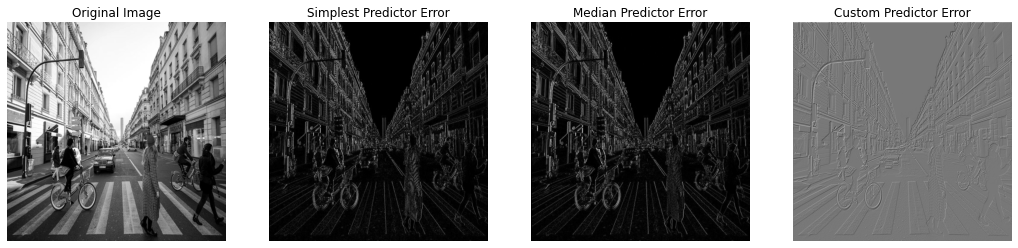

Processing Image 2
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


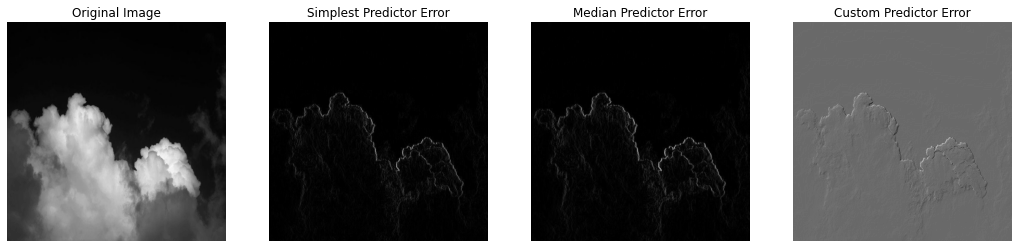

Processing Image 3
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


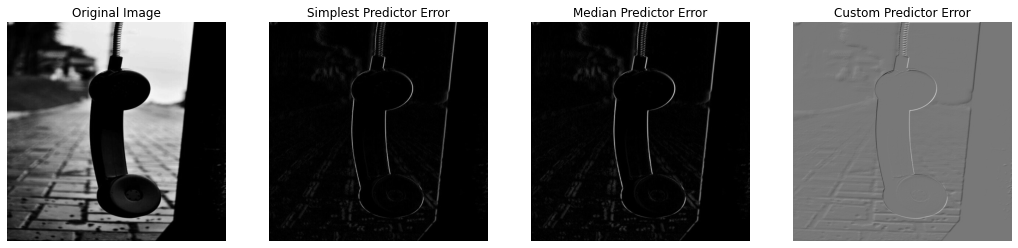

Processing Image 4
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


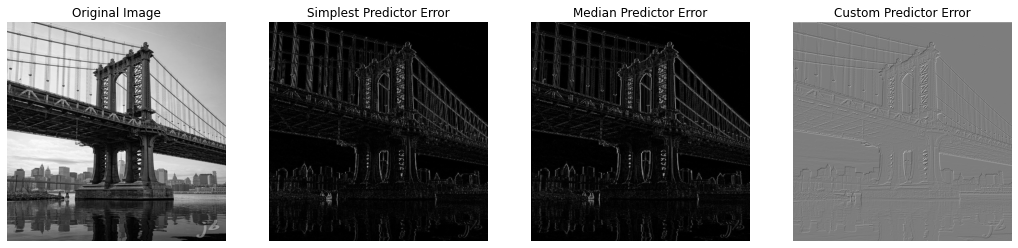

Processing Image 5
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


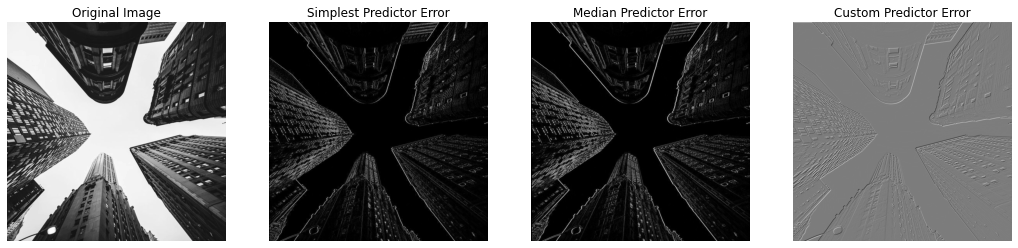

Processing Image 6
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


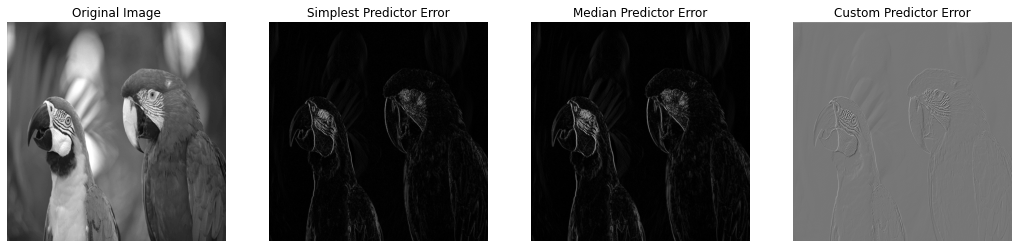

Processing Image 7
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


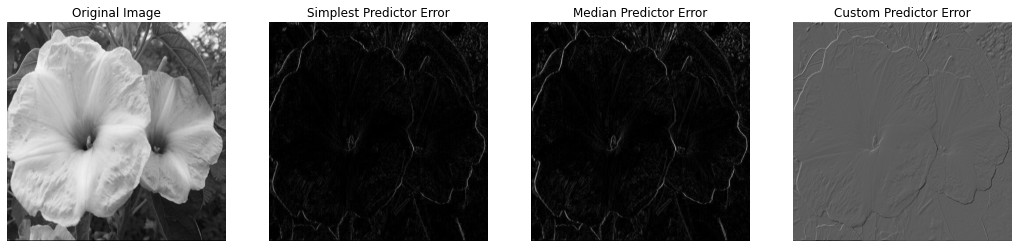

Processing Image 8
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


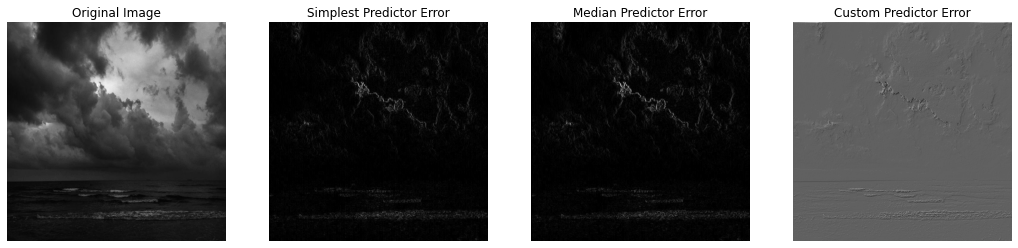

Processing Image 9
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


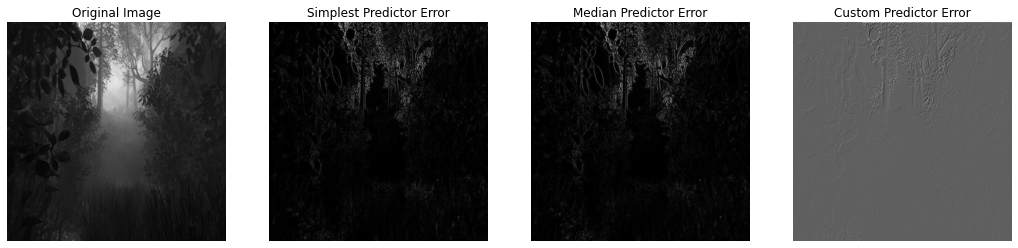

Processing Image 10
Task 1 (a): Simplest predictor applied successfully
Task 1 (b): Median predictor successfully applied
Task 1 (c): Custom predictor successfully applied


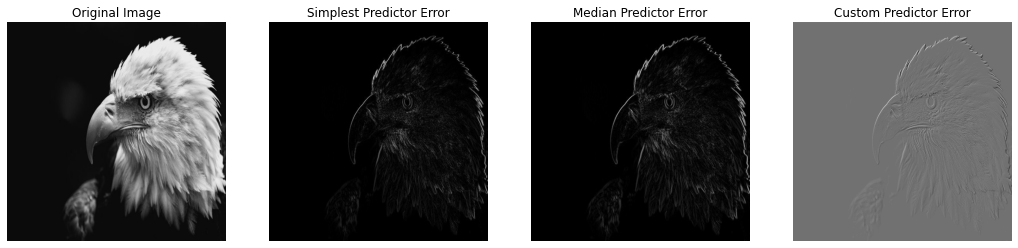

In [5]:
# Function to plot the original image and the error images for different predictors
def plot_images(original, simplest_error, median_error, custom_error):
    plt.figure(figsize=(18, 6))
    
    # Plot original image once
    plt.subplot(1, 4, 1)
    plt.title("Original Image")
    plt.imshow(original, cmap='gray')
    plt.axis('off')  # Hide axes for clarity

    # Plot error from Simplest Predictor
    plt.subplot(1, 4, 2)
    plt.title("Simplest Predictor Error")
    plt.imshow(simplest_error, cmap='gray')
    plt.axis('off')

    # Plot error from Median Predictor
    plt.subplot(1, 4, 3)
    plt.title("Median Predictor Error")
    plt.imshow(median_error, cmap='gray')
    plt.axis('off')

    # Plot error from Custom Predictor
    plt.subplot(1, 4, 4)
    plt.title("Custom Predictor Error")
    plt.imshow(custom_error, cmap='gray')
    plt.axis('off')

    # Show all the plots together
    plt.show()


# Main function to process the images
def main():
    image_folder = r"E:\University\7th Semester\DIP Lab\Lab 9\Images"
    
    # List all files in the directory and filter by common image extensions
    valid_extensions = ['.jpeg', '.png', '.jpg', '.bmp', '.gif']
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if any(f.endswith(ext) for ext in valid_extensions)]
    
    if not image_paths:
        print("No valid images found in the specified directory.")
        return

    # Resize images to 500x500
    images = process_and_resize_images(image_paths)

    # Process and plot results for each image
    for idx, img in enumerate(images):
        print(f"Processing Image {idx + 1}")

        # Apply predictors and calculate errors
        simplest_error = simplest_predictor(img)
        median_error = median_predictor(img)
        custom_error = custom_predictor(img)

        # Plot the original image and the errors for each predictor
        plot_images(img, simplest_error, median_error, custom_error)


# Run the main function
if __name__ == "__main__":
    main()

# After the predictive coding, use Huffman coding for the final compressed output and calculate the compression ratio.

In [6]:
import os
from collections import Counter
import heapq
import numpy as np
from PIL import Image


class HuffmanNode:
    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(frequencies):
    heap = [HuffmanNode(freq, symbol) for symbol, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = HuffmanNode(left.freq + right.freq, left=left, right=right)
        heapq.heappush(heap, merged)

    return heap[0]


def generate_huffman_codes(node, prefix="", codes={}):
    if node.symbol is not None:
        codes[node.symbol] = prefix
        return codes
    if node.left:
        generate_huffman_codes(node.left, prefix + "0", codes)
    if node.right:
        generate_huffman_codes(node.right, prefix + "1", codes)
    return codes


def huffman_compress(data):
    flattened_data = data.flatten()
    frequencies = Counter(flattened_data)
    huffman_tree = build_huffman_tree(frequencies)
    codes = generate_huffman_codes(huffman_tree)

    encoded_data = "".join(codes[value] for value in flattened_data)
    return frequencies, codes, encoded_data


def calculate_compression_ratio(original_size, encoded_data):
    compressed_size = len(encoded_data) / 8
    compression_ratio = original_size / compressed_size
    return compression_ratio


def simplest_predictor(image):
    rows, cols = image.shape
    prediction_error = np.zeros((rows, cols), dtype=np.int16)
    for i in range(rows):
        for j in range(cols):
            if j == 0:  # First column, no left pixel
                prediction_error[i, j] = image[i, j]
            else:
                prediction_error[i, j] = int(image[i, j]) - int(image[i, j - 1])
    return prediction_error


def resize_images(image_paths, size=(500, 500)):
    images = []
    for path in image_paths:
        img = Image.open(path).convert("L").resize(size)
        images.append(np.array(img))
    return images


def main_huffman(images, predictor):
    for idx, img in enumerate(images):
        print(f"\nProcessing Image {idx + 1}")
        print("-" * 50)

        prediction_error = predictor(img)

        # Calculate the original image size in bytes (width * height)
        original_size = img.shape[0] * img.shape[1]  # width * height from numpy array shape

        frequencies, codes, encoded_data = huffman_compress(prediction_error)

        compression_ratio = calculate_compression_ratio(original_size, encoded_data)

        print(f"Original Image Size (bytes): {original_size}")
        print(f"Encoded Data Length: {len(encoded_data)} bits")
        print(f"Compression Ratio: {compression_ratio:.2f}")
        print("\nSample Huffman Codes:")
        for symbol, code in list(codes.items())[:5]:
            print(f"  Symbol: {symbol}, Code: {code}")
        print("-" * 50)


def main():
    # Set the folder path for images
    image_folder = r"E:\University\7th Semester\DIP Lab\Lab 9\Images"
    
    # List all files in the directory and filter by common image extensions
    valid_extensions = ['.jpeg', '.png', '.jpg', '.bmp', '.gif']
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if any(f.endswith(ext) for ext in valid_extensions)]
    
    if not image_paths:
        print("No valid images found in the specified directory.")
        return

    # Resize images to 500x500
    images = resize_images(image_paths)

    # Apply Huffman Coding using Simplest Predictor
    print("\nApplying Huffman Coding using Simplest Predictor...")
    main_huffman(images, simplest_predictor)


# Run the main function
if __name__ == "__main__":
    main()



Applying Huffman Coding using Simplest Predictor...

Processing Image 1
--------------------------------------------------
Original Image Size (bytes): 250000
Encoded Data Length: 1518694 bits
Compression Ratio: 1.32

Sample Huffman Codes:
  Symbol: -18, Code: 0000000
  Symbol: -33, Code: 00000010
  Symbol: 35, Code: 00000011
  Symbol: -91, Code: 00000100000
  Symbol: 109, Code: 000001000010
--------------------------------------------------

Processing Image 2
--------------------------------------------------
Original Image Size (bytes): 250000
Encoded Data Length: 683431 bits
Compression Ratio: 2.93

Sample Huffman Codes:
  Symbol: -18, Code: 01100101001
  Symbol: -33, Code: 0110010111011
  Symbol: 35, Code: 0011010110101
  Symbol: -91, Code: 00000100000
  Symbol: 109, Code: 000001000010
--------------------------------------------------

Processing Image 3
--------------------------------------------------
Original Image Size (bytes): 250000
Encoded Data Length: 826839 bits
Compre

# Apply Huffman coding on the original images as well and calculate the compression ratio.

In [7]:
import os
from collections import Counter
import heapq
import numpy as np
from PIL import Image


class HuffmanNode:
    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(frequencies):
    heap = [HuffmanNode(freq, symbol) for symbol, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = HuffmanNode(left.freq + right.freq, left=left, right=right)
        heapq.heappush(heap, merged)

    return heap[0]


def generate_huffman_codes(node, prefix="", codes={}):
    if node.symbol is not None:
        codes[node.symbol] = prefix
        return codes
    if node.left:
        generate_huffman_codes(node.left, prefix + "0", codes)
    if node.right:
        generate_huffman_codes(node.right, prefix + "1", codes)
    return codes


def huffman_compress(data):
    flattened_data = data.flatten()
    frequencies = Counter(flattened_data)
    huffman_tree = build_huffman_tree(frequencies)
    codes = generate_huffman_codes(huffman_tree)

    encoded_data = "".join(codes[value] for value in flattened_data)
    return frequencies, codes, encoded_data


def calculate_compression_ratio(original_size, encoded_data):
    compressed_size = len(encoded_data) / 8
    compression_ratio = original_size / compressed_size
    return compression_ratio


def simplest_predictor(image):
    rows, cols = image.shape
    prediction_error = np.zeros((rows, cols), dtype=np.int16)
    for i in range(rows):
        for j in range(cols):
            if j == 0:  # First column, no left pixel
                prediction_error[i, j] = image[i, j]
            else:
                prediction_error[i, j] = int(image[i, j]) - int(image[i, j - 1])
    return prediction_error


def resize_images(image_paths, size=(500, 500)):
    images = []
    for path in image_paths:
        img = Image.open(path).convert("L").resize(size)
        images.append(np.array(img))
    return images


def main_huffman(images, predictor):
    for idx, img in enumerate(images):
        print(f"\nProcessing Image {idx + 1}")
        print("-" * 50)

        # Calculate original image size
        original_size = img.shape[0] * img.shape[1]  # width * height from numpy array shape

        # Huffman coding for the original image
        _, orig_codes, orig_encoded_data = huffman_compress(img)
        orig_compression_ratio = calculate_compression_ratio(original_size, orig_encoded_data)

        print(f"Original Image Compression Ratio: {orig_compression_ratio:.2f}")
        print("\nSample Huffman Codes for Original Image:")
        for symbol, code in list(orig_codes.items())[:5]:
            print(f"  Symbol: {symbol}, Code: {code}")

        print("-" * 50)

        # Prediction error using the provided predictor
        prediction_error = predictor(img)

        # Huffman coding for the prediction error
        _, pred_codes, pred_encoded_data = huffman_compress(prediction_error)
        pred_compression_ratio = calculate_compression_ratio(original_size, pred_encoded_data)

        print(f"Prediction Error Compression Ratio: {pred_compression_ratio:.2f}")
        print("\nSample Huffman Codes for Prediction Error:")
        for symbol, code in list(pred_codes.items())[:5]:
            print(f"  Symbol: {symbol}, Code: {code}")
        print("-" * 50)


def main():
    # Set the folder path for images
    image_folder = r"E:\University\7th Semester\DIP Lab\Lab 9\Images"
    
    # List all files in the directory and filter by common image extensions
    valid_extensions = ['.jpeg', '.png', '.jpg', '.bmp', '.gif']
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if any(f.endswith(ext) for ext in valid_extensions)]
    
    if not image_paths:
        print("No valid images found in the specified directory.")
        return

    # Resize images to 500x500
    images = resize_images(image_paths)

    # Apply Huffman Coding using Simplest Predictor
    print("\nApplying Huffman Coding on Original and Prediction Error Images...")
    main_huffman(images, simplest_predictor)


# Run the main function
if __name__ == "__main__":
    main()



Applying Huffman Coding on Original and Prediction Error Images...

Processing Image 1
--------------------------------------------------
Original Image Compression Ratio: 1.02

Sample Huffman Codes for Original Image:
  Symbol: 77, Code: 0000000
  Symbol: 83, Code: 0000001
  Symbol: 234, Code: 00000100
  Symbol: 20, Code: 00000101
  Symbol: 76, Code: 0000011
--------------------------------------------------
Prediction Error Compression Ratio: 1.32

Sample Huffman Codes for Prediction Error:
  Symbol: 77, Code: 11100000011
  Symbol: 83, Code: 10011010011
  Symbol: 234, Code: 1010000101110001
  Symbol: 20, Code: 11100100
  Symbol: 76, Code: 11111011010
--------------------------------------------------

Processing Image 2
--------------------------------------------------
Original Image Compression Ratio: 1.19

Sample Huffman Codes for Original Image:
  Symbol: 77, Code: 011100111
  Symbol: 83, Code: 110010000
  Symbol: 234, Code: 010101110111
  Symbol: 20, Code: 11101000
  Symbol: 76

# For all 10 images, report the results of compression with and without predictive coding.

In [8]:
import os
from collections import Counter
import heapq
import numpy as np
from PIL import Image
from tabulate import tabulate  # For better table formatting

class HuffmanNode:
    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(frequencies):
    heap = [HuffmanNode(freq, symbol) for symbol, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = HuffmanNode(left.freq + right.freq, left=left, right=right)
        heapq.heappush(heap, merged)

    return heap[0]


def generate_huffman_codes(node, prefix="", codes={}):
    if node.symbol is not None:
        codes[node.symbol] = prefix
        return codes
    if node.left:
        generate_huffman_codes(node.left, prefix + "0", codes)
    if node.right:
        generate_huffman_codes(node.right, prefix + "1", codes)
    return codes


def huffman_compress(data):
    flattened_data = data.flatten()
    frequencies = Counter(flattened_data)
    huffman_tree = build_huffman_tree(frequencies)
    codes = generate_huffman_codes(huffman_tree)

    encoded_data = "".join(codes[value] for value in flattened_data)
    return frequencies, codes, encoded_data


def calculate_compression_ratio(original_size, encoded_data):
    compressed_size = len(encoded_data) / 8
    compression_ratio = original_size / compressed_size
    return compression_ratio


def simplest_predictor(image):
    rows, cols = image.shape
    prediction_error = np.zeros((rows, cols), dtype=np.int16)
    for i in range(rows):
        for j in range(cols):
            if j == 0:  # First column, no left pixel
                prediction_error[i, j] = image[i, j]
            else:
                prediction_error[i, j] = int(image[i, j]) - int(image[i, j - 1])
    return prediction_error


def resize_images(image_paths, size=(500, 500)):
    images = []
    for path in image_paths:
        img = Image.open(path).convert("L").resize(size)
        images.append(np.array(img))
    return images


def main_huffman(images, predictor):
    results = []

    for idx, img in enumerate(images):
        print(f"\nProcessing Image {idx + 1}")
        print("-" * 50)

        # Calculate original image size
        original_size = img.shape[0] * img.shape[1]  # width * height from numpy array shape

        # Huffman coding for the original image
        _, orig_codes, orig_encoded_data = huffman_compress(img)
        orig_compression_ratio = calculate_compression_ratio(original_size, orig_encoded_data)

        print(f"Original Image Compression Ratio: {orig_compression_ratio:.2f}")

        results.append({
            "image": idx + 1,
            "original_compression_ratio": orig_compression_ratio,
            "prediction_error_compression_ratio": None,
        })

        print("\nSample Huffman Codes for Original Image:")
        for symbol, code in list(orig_codes.items())[:5]:
            print(f"  Symbol: {symbol}, Code: {code}")

        print("-" * 50)

        # Calculate prediction error using the predictor
        prediction_error = predictor(img)

        # Huffman coding for the prediction error
        _, pred_codes, pred_encoded_data = huffman_compress(prediction_error)
        pred_compression_ratio = calculate_compression_ratio(original_size, pred_encoded_data)

        print(f"Prediction Error Compression Ratio: {pred_compression_ratio:.2f}")
        print("\nSample Huffman Codes for Prediction Error:")
        for symbol, code in list(pred_codes.items())[:5]:
            print(f"  Symbol: {symbol}, Code: {code}")

        print("-" * 50)

        # Store the results
        results[-1]["prediction_error_compression_ratio"] = pred_compression_ratio

    return results


def main():
    # Set the folder path for images
    image_folder = r"E:\University\7th Semester\DIP Lab\Lab 9\Images"
    
    # List all files in the directory and filter by common image extensions
    valid_extensions = ['.jpeg', '.png', '.jpg', '.bmp', '.gif']
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if any(f.endswith(ext) for ext in valid_extensions)]
    
    if not image_paths:
        print("No valid images found in the specified directory.")
        return

    # Resize images to 500x500
    images = resize_images(image_paths)

    # Apply Huffman Coding using Simplest Predictor
    print("\nApplying Huffman Coding on Original and Prediction Error Images...")
    results = main_huffman(images, simplest_predictor)

    # Prepare the summary data for table display
    summary_data = [
        [result["image"], f"{result['original_compression_ratio']:.2f}", f"{result['prediction_error_compression_ratio']:.2f}"]
        for result in results
    ]

    # Print the summary table
    print("\nSummary of Compression Results:")
    headers = ["Image", "Original Compression Ratio", "Prediction Error Compression Ratio"]
    print(tabulate(summary_data, headers=headers, tablefmt="grid"))


# Run the main function
if __name__ == "__main__":
    main()



Applying Huffman Coding on Original and Prediction Error Images...

Processing Image 1
--------------------------------------------------
Original Image Compression Ratio: 1.02

Sample Huffman Codes for Original Image:
  Symbol: 77, Code: 0000000
  Symbol: 83, Code: 0000001
  Symbol: 234, Code: 00000100
  Symbol: 20, Code: 00000101
  Symbol: 76, Code: 0000011
--------------------------------------------------
Prediction Error Compression Ratio: 1.32

Sample Huffman Codes for Prediction Error:
  Symbol: 77, Code: 11100000011
  Symbol: 83, Code: 10011010011
  Symbol: 234, Code: 1010000101110001
  Symbol: 20, Code: 11100100
  Symbol: 76, Code: 11111011010
--------------------------------------------------

Processing Image 2
--------------------------------------------------
Original Image Compression Ratio: 1.19

Sample Huffman Codes for Original Image:
  Symbol: 77, Code: 011100111
  Symbol: 83, Code: 110010000
  Symbol: 234, Code: 010101110111
  Symbol: 20, Code: 11101000
  Symbol: 76